# Solving for a Standard Mirrleesian Economy by Using MWY (2009)'s Fixed-Point Iteration Method
> Written by George Chou, August 8, 2026.

## 1. Preparation

In [8]:
# file path of simulation data
DATA_FILE_PATH = 'D:/Desktop/input_data.txt'

In [2]:
import numpy as np
from scipy.optimize import minimize_scalar, root_scalar
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [10, 6]

## 2. Computing the Consumption Level

In [3]:
def compute_consumption(l_i, i, w, y, tax_marg, transfer):
    y_i = w[i] * l_i
    y[i] = y_i

    # find the tax level
    j = 0
    while (j != i) and (y[j] < y_i):
        j += 1

    # calc the tax payment
    if j == 0:
        tax_paid_i = tax_marg[0] * y_i
    elif j == 1:
        tax_paid_i = tax_marg[0] * y[0] + tax_marg[1] * (y_i - y[0])
    else:
        tax_paid_i = (tax_marg[0] * y[0] +
                      np.sum(tax_marg[1:j] * np.diff(y[:j])) +
                      tax_marg[j] * (y_i - y[j-1]))

    return transfer + y_i - tax_paid_i

## 3. Defining the Objective Function

In [4]:
def neg_utility(l_opt_i, i, w, y, tax_marg, transfer, gamma, alpha, sigma):
    c_i = compute_consumption(l_opt_i, i, w, y, tax_marg, transfer)

    if gamma == 1:
        u_c = np.log(c_i)
    else:
        u_c = (c_i**(1 - gamma) - 1) / (1 - gamma)

    v_l = -alpha * (l_opt_i**sigma) / sigma
    utility = u_c + v_l

    return -utility

## 4. Finding the Optimal Labor Supply

In [5]:
def find_optimal_labor(num_wages, transfer, tax_marg, w,
                       guess_for_lowest_wage, lb, ub,
                       gamma, alpha, sigma, use_parallel=True):
    l = np.zeros(num_wages)
    y = np.zeros(num_wages)

    def optimize_individual(i, guess):
        result = minimize_scalar(
            neg_utility,
            args=(i, w, y.copy(), tax_marg, transfer, gamma, alpha, sigma),
            method='bounded',
            bounds=(lb, 1e6),
            options={'xatol': 1e-13, 'maxiter': 1000}
        )
        if result.success:
            l_opt = result.x
        else:
            # alternative way: using the FOC to solve the roots
            try:
                def foc(l_opt):
                    c_opt = compute_consumption(l_opt, i, w, y.copy(), tax_marg, transfer)
                    mu_c = c_opt**(-gamma)
                    mu_l = alpha * l_opt**(sigma - 1)
                    return mu_c * (1 - tax_marg[i]) - mu_l

                result_root = root_scalar(foc, bracket=[lb, 1e6], method='bisect')
                if result_root.converged:
                    l_opt = result_root.root
                else:
                    l_opt = guess
            except:
                l_opt = guess

        return l_opt, w[i] * l_opt

    if use_parallel:
        with ThreadPoolExecutor(max_workers=4) as executor:
            futures = []
            guess = guess_for_lowest_wage
            for i in range(num_wages):
                future = executor.submit(optimize_individual, i, guess)
                futures.append(future)
                guess = l[i] if i > 0 else guess_for_lowest_wage

            for i, future in enumerate(futures):
                l_opt, y_opt = future.result()
                l[i] = l_opt
                y[i] = y_opt
    else:
        guess = guess_for_lowest_wage
        for i in range(num_wages):
            l_opt, y_opt = optimize_individual(i, guess)
            l[i] = l_opt
            y[i] = y_opt
            guess = l_opt

    return l, y

## 5. Main Execution Function

In [12]:
def run_mirrlees_simulation(input_data,
                           gamma=1.5, alpha=2.55, sigma=3,
                           initial_tax=0.35,
                           tolerance_gov_bc=1e-6,
                           tolerance_tax_dev=1e-6,
                           max_iterations=1000,
                           use_parallel=True):
    # prepare for introducing the simulation data
    wage_orig = input_data[:, 0]
    cdf_orig = input_data[:, 1]

    num_wages = len(wage_orig) - 1

    w = (wage_orig[:num_wages] + wage_orig[1:num_wages+1]) / 2
    bin_width = w[1] - w[0]

    pmf = cdf_orig[1:num_wages+1] - cdf_orig[:num_wages]
    pmf = pmf / pmf.sum()
    cdf = np.cumsum(pmf)
    pmf_over_bin_width = pmf / bin_width

    # initialize
    tax_marg = initial_tax * np.ones(num_wages)
    transfer = 0.000001

    tax_marg_history = [tax_marg.copy()]
    gov_surplus_history = []

    loop = 0
    gov_imbalance_percent_gni = -np.inf
    max_percent_tax_deviation = -np.inf

    print("=" * 60)
    print("Begin to run the fixed-point iteration algorithm:")
    print("=" * 60)

    # main loop
    while ((abs(gov_imbalance_percent_gni) > tolerance_gov_bc or
            abs(max_percent_tax_deviation) > tolerance_tax_dev) and
           loop < max_iterations):

        loop += 1

        # Step 1: given tax rate schedule and transfer, find the optimal labor supply
        l, y = find_optimal_labor(num_wages, transfer, tax_marg, w,
                                 0.1, 0, np.inf, gamma, alpha, sigma, use_parallel)

        # calc the consumption level
        c = np.zeros(num_wages)
        for i in range(num_wages):
            c[i] = compute_consumption(l[i], i, w, y, tax_marg, transfer)

        # Step 2: calc each terms in FOC
        elas_comp = 1 / (sigma - 1 + alpha * gamma * l**sigma * c**(gamma - 1))
        elas_uncomp = (1 - alpha * gamma * l**sigma * c**(gamma - 1)) / (sigma - 1 + alpha * gamma * l**sigma * c**(gamma - 1))

        u_prime_c = c**(-gamma)
        total_marg_soc_value = np.sum(pmf / u_prime_c)

        marg_soc_value_above_w = np.zeros(num_wages)
        for k in range(num_wages):
            marg_soc_value_above_w[k] = total_marg_soc_value - np.sum(pmf[:k+1] / u_prime_c[:k+1])

        # calc the alternative schedule by FOC
        tax_marg_foc_rhs = ((1 + elas_uncomp) / elas_comp *
                           1 / (w * pmf_over_bin_width) *
                           u_prime_c *
                           (marg_soc_value_above_w - total_marg_soc_value * (1 - cdf)))

        tax_marg_alternative = tax_marg_foc_rhs / (1 + tax_marg_foc_rhs)

        # Step 3: update the schedule
        tax_marg = (tax_marg + tax_marg_alternative) / 2
        max_percent_tax_deviation = np.max(100 * np.abs(tax_marg_alternative - tax_marg) / tax_marg)

        tax_marg_history.append(tax_marg.copy())

        # Step 4: recalc the allocations
        l_new, y_new = find_optimal_labor(num_wages, transfer, tax_marg, w,
                                        0.1, 0, np.inf, gamma, alpha, sigma, use_parallel)

        c_new = np.zeros(num_wages)
        for i in range(num_wages):
            c_new[i] = compute_consumption(l_new[i], i, w, y_new, tax_marg, transfer)

        tax_paid = y_new + transfer - c_new
        gov_rev = np.sum(tax_paid * pmf)
        gov_surplus = np.sum((tax_paid - transfer) * pmf)

        gov_surplus_history.append(gov_surplus)

        transfer = gov_rev
        gov_imbalance_percent_gni = 100 * gov_surplus / np.sum(y_new * pmf)

        y = y_new
        l = l_new
        c = c_new

        if loop % 10 == 0:
            print(f"Iteration {loop}: government budget surplus = {gov_imbalance_percent_gni:.6f}%, "
                  f"maximal deviation of tax rate = {max_percent_tax_deviation:.6f}%")

    print(f"\niteration ends with {loop} times")
    print(f"eventual government budget surplus: {gov_imbalance_percent_gni:.6f}%")
    print(f"eventual maximal deviation of tax rate: {max_percent_tax_deviation:.6f}%")

    # ---- chenck the IC condition ----
    print("\ncheck the IC condition...")
    IC_check = np.zeros((num_wages, num_wages))
    max_IC_violation = 0

    for i in range(num_wages):
        for m in range(num_wages):
            u_true = (c[i]**(1 - gamma) - 1) / (1 - gamma) - alpha * l[i]**sigma / sigma
            y_m = w[i] * (y[m] / w[m])
            l_m = y_m / w[i]
            c_m = compute_consumption(l_m, i, w, y, tax_marg, transfer)
            u_fake = (c_m**(1 - gamma) - 1) / (1 - gamma) - alpha * l_m**sigma / sigma
            IC_check[i, m] = u_true - u_fake
            if -IC_check[i, m] > max_IC_violation:
                max_IC_violation = -IC_check[i, m]

    y_non_decreasing = np.all(np.diff(y) >= 0)

    # ---- summary ----
    results = {
        'w': w,
        'tax_marg': tax_marg,
        'l': l,
        'y': y,
        'c': c,
        'pmf': pmf,
        'cdf': cdf,
        'transfer': transfer,
        'gov_imbalance_percent_gni': gov_imbalance_percent_gni,
        'max_percent_tax_deviation': max_percent_tax_deviation,
        'loop': loop,
        'y_non_decreasing': y_non_decreasing,
        'max_IC_violation': max_IC_violation,
        'tax_marg_history': tax_marg_history,
        'gov_surplus_history': gov_surplus_history
    }

    return results

## 6. Input the Data of Wage Distribution

In [10]:
data = np.loadtxt(DATA_FILE_PATH)

wage_orig = data[:, 0]
cdf_orig = data[:, 1]

input_data = np.column_stack([wage_orig, cdf_orig])

# calc the discrete distribution
num_wages = len(wage_orig) - 1
w = (wage_orig[:num_wages] + wage_orig[1:num_wages+1]) / 2
pmf = cdf_orig[1:num_wages+1] - cdf_orig[:num_wages]
pmf = pmf / pmf.sum()
cdf = np.cumsum(pmf)

print("=" * 60)
print("input the data successfully")
print("=" * 60)
print(f"numbers: {num_wages}")
print(f"scope: from {w.min():.2f} to {w.max():.2f}")
print(f"sum of PMF: {pmf.sum():.6f}")

input the data successfully
numbers: 144
scope: from 0.01 to 500.51
sum of PMF: 1.000000


## 7. Running Simulation

In [13]:
print("\nBegin to simulate:")
results = run_mirrlees_simulation(
    input_data,
    gamma=1.5, alpha=2.55, sigma=3,
    initial_tax=0.35,
    tolerance_gov_bc=1e-5,
    tolerance_tax_dev=1e-5,
    max_iterations=200,
    use_parallel=True
)


Begin to simulate:
Begin to run the fixed-point iteration algorithm:
Iteration 10: government budget surplus = -0.064032%, maximal deviation of tax rate = 100.000000%
Iteration 20: government budget surplus = -0.066617%, maximal deviation of tax rate = 100.000011%
Iteration 30: government budget surplus = 0.189954%, maximal deviation of tax rate = 100.010810%
Iteration 40: government budget surplus = 0.005785%, maximal deviation of tax rate = 113.103554%
Iteration 50: government budget surplus = 0.162193%, maximal deviation of tax rate = 0.341588%
Iteration 60: government budget surplus = -0.061484%, maximal deviation of tax rate = 0.343425%
Iteration 70: government budget surplus = -0.034401%, maximal deviation of tax rate = 1.648465%
Iteration 80: government budget surplus = -0.106048%, maximal deviation of tax rate = 0.359251%
Iteration 90: government budget surplus = 0.135153%, maximal deviation of tax rate = 0.873335%
Iteration 100: government budget surplus = -0.036004%, maximal

## 8. Plotting the Results

In [14]:
print("\n" + "=" * 60)
print("summary")
print("=" * 60)
print(f"times of iteration: {results['loop']}")
print(f"non-decreasing of y(w): {results['y_non_decreasing']}")
print(f"maximal violation of IC condition: {results['max_IC_violation']:.6f}")
print(f"lowest marginal tax rate: {results['tax_marg'].min():.4f}")
print(f"highest marginal tax rate: {results['tax_marg'].max():.4f}")
print(f"transfer: {results['transfer']:.4f}")
print(f"government budget surplus (%): {results['gov_imbalance_percent_gni']:.6f}%")
print(f"maximal deviation of tax rate (%): {results['max_percent_tax_deviation']:.6f}%")


summary
times of iteration: 200
non-decreasing of y(w): True
maximal violation of IC condition: 0.008916
lowest marginal tax rate: -0.0000
highest marginal tax rate: 0.9992
transfer: 4.7668
government budget surplus (%): 0.007948%
maximal deviation of tax rate (%): 0.245709%


## 9. Illustration

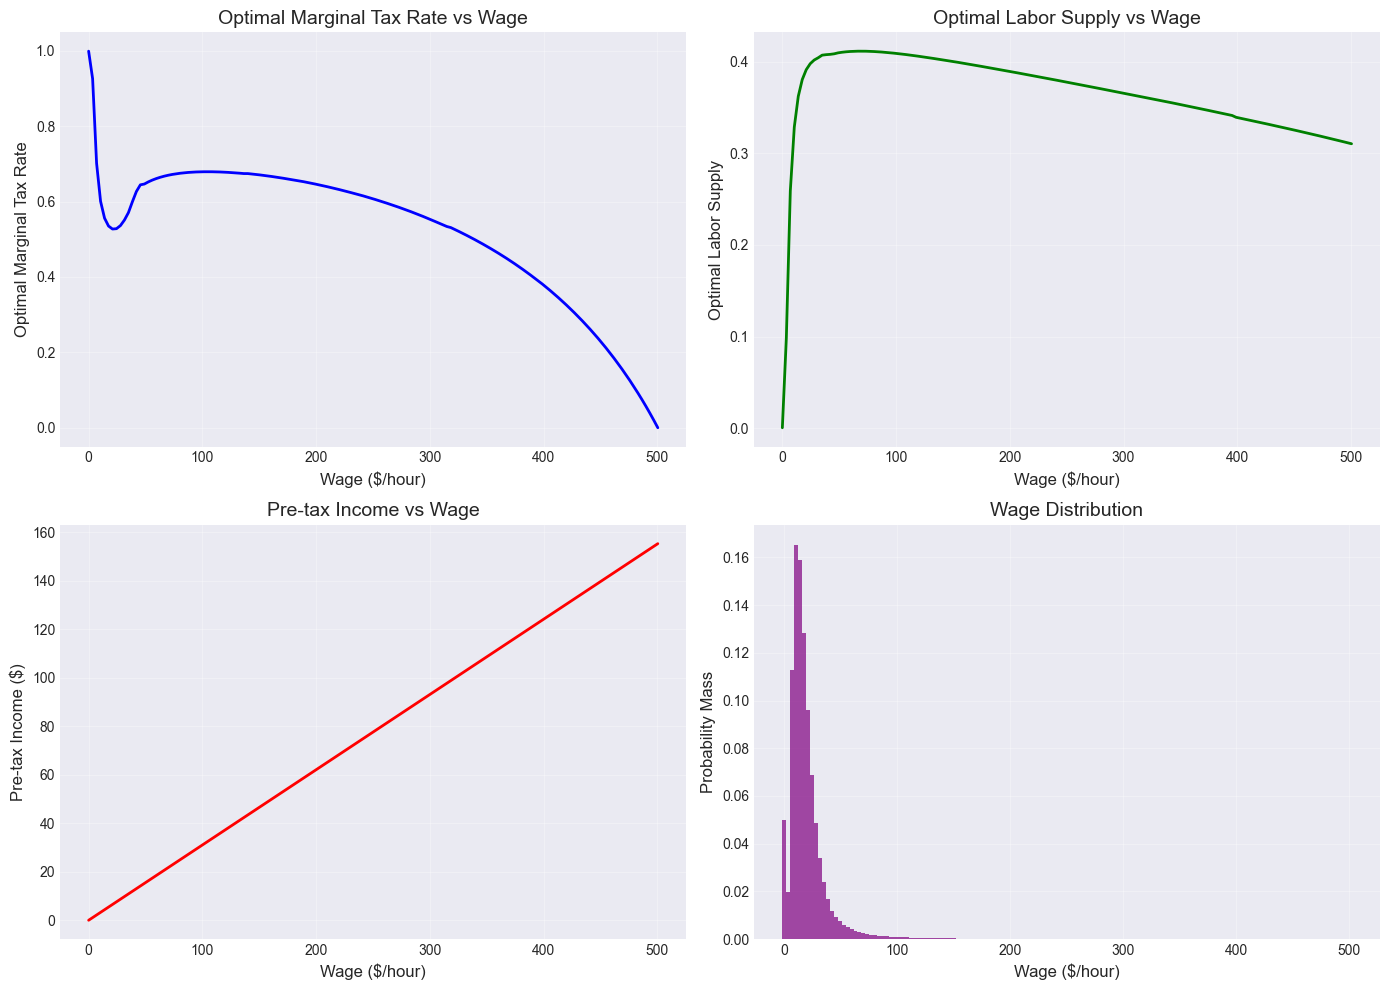

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. optimal marginal tax rate schedule
axes[0, 0].plot(results['w'], results['tax_marg'], 'b-', linewidth=2)
axes[0, 0].set_xlabel('Wage ($/hour)', fontsize=12)
axes[0, 0].set_ylabel('Optimal Marginal Tax Rate', fontsize=12)
axes[0, 0].set_title('Optimal Marginal Tax Rate vs Wage', fontsize=14)
axes[0, 0].grid(True, alpha=0.3)

# 2. optimal labor supply
axes[0, 1].plot(results['w'], results['l'], 'g-', linewidth=2)
axes[0, 1].set_xlabel('Wage ($/hour)', fontsize=12)
axes[0, 1].set_ylabel('Optimal Labor Supply', fontsize=12)
axes[0, 1].set_title('Optimal Labor Supply vs Wage', fontsize=14)
axes[0, 1].grid(True, alpha=0.3)

# 3. pre-tax income
axes[1, 0].plot(results['w'], results['y'], 'r-', linewidth=2)
axes[1, 0].set_xlabel('Wage ($/hour)', fontsize=12)
axes[1, 0].set_ylabel('Pre-tax Income ($)', fontsize=12)
axes[1, 0].set_title('Pre-tax Income vs Wage', fontsize=14)
axes[1, 0].grid(True, alpha=0.3)

# 4. wage distribution
axes[1, 1].bar(results['w'], results['pmf'], width=np.mean(np.diff(results['w'])), alpha=0.7, color='purple')
axes[1, 1].set_xlabel('Wage ($/hour)', fontsize=12)
axes[1, 1].set_ylabel('Probability Mass', fontsize=12)
axes[1, 1].set_title('Wage Distribution', fontsize=14)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Transition Dynamics

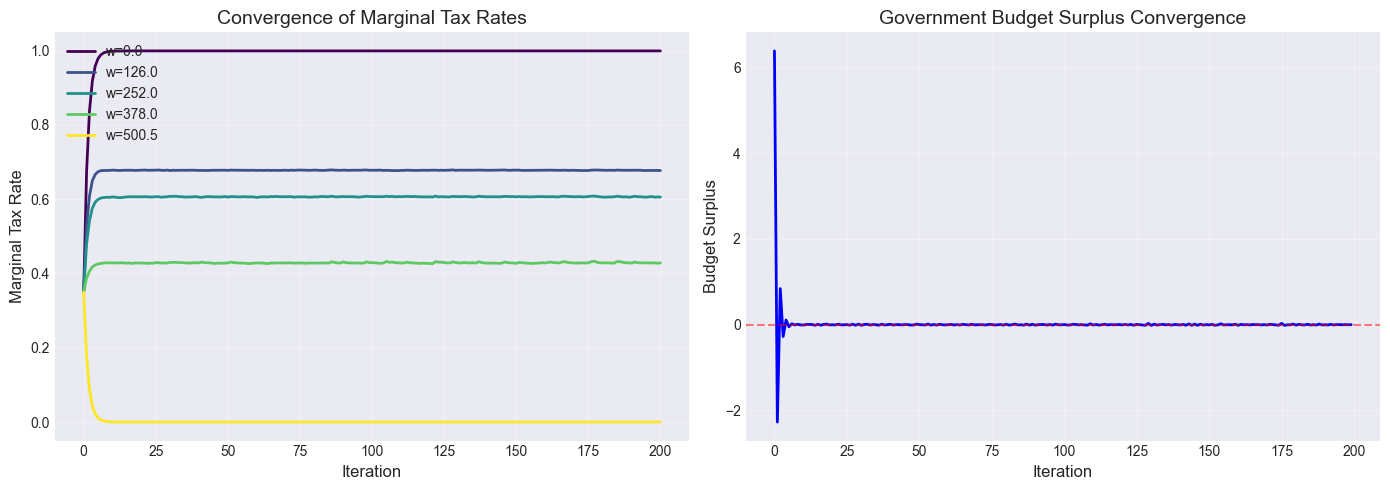

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# dynamics of tax rate
tax_history = results['tax_marg_history']
if len(tax_history) > 1:
    plot_indices = [0, len(results['w'])//4, len(results['w'])//2, 3*len(results['w'])//4, -1]
    colors = plt.cm.viridis(np.linspace(0, 1, len(plot_indices)))
    for idx, w_idx in enumerate(plot_indices):
        if w_idx < 0:
            w_idx = len(results['w']) + w_idx
        values = [tax[w_idx] for tax in tax_history]
        axes[0].plot(range(len(values)), values,
                    label=f'w={results["w"][w_idx]:.1f}',
                    color=colors[idx], linewidth=2)
    axes[0].set_xlabel('Iteration', fontsize=12)
    axes[0].set_ylabel('Marginal Tax Rate', fontsize=12)
    axes[0].set_title('Convergence of Marginal Tax Rates', fontsize=14)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# dynamics of government budget imbalance
if len(results['gov_surplus_history']) > 0:
    axes[1].plot(results['gov_surplus_history'], 'b-', linewidth=2)
    axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    axes[1].set_xlabel('Iteration', fontsize=12)
    axes[1].set_ylabel('Budget Surplus', fontsize=12)
    axes[1].set_title('Government Budget Surplus Convergence', fontsize=14)
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()